# Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler, OneHotEncoder
import os
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, f1_score, roc_curve, auc, accuracy_score
import joblib


# Data loading

In [2]:
df_tr = pd.read_csv('train.csv')

In [3]:
df_tr.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15779985.0,Nwankwo,678.0,France,Male,29.0,4.0,0.00,3.0,1.0,0.0,180626.36,0.0
1,1,15650086.0,Ch'in,687.0,France,Female,34.0,1.0,0.00,2.0,0.0,1.0,63736.17,0.0
2,2,15733602.0,Thompson,682.0,France,Female,52.0,6.0,0.00,3.0,0.0,0.0,179655.87,1.0
3,3,15645794.0,Macleod,753.0,Germany,Male,44.0,6.0,83347.25,2.0,1.0,0.0,161407.48,0.0
4,4,15633840.0,Hsia,544.0,Germany,Female,55.0,0.0,107747.57,1.0,1.0,0.0,176580.86,1.0


In [4]:
train_df, valid_df = train_test_split(df_tr, test_size=0.2, random_state=42, stratify=df_tr['Exited'])

In [5]:
print("Розмір навчальної вибірки:", train_df.shape)
print("Розмір валідаційної вибірки:", valid_df.shape)

Розмір навчальної вибірки: (12000, 14)
Розмір валідаційної вибірки: (3000, 14)


In [6]:
target_col = 'Exited'
inputs_cols = ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']

train_targets = train_df[target_col].copy()
val_targets = valid_df[target_col].copy()

train_inputs = train_df[inputs_cols].copy()
val_inputs = valid_df[inputs_cols].copy()

In [7]:
print("Цільова змінна навчального набору")
display(train_targets.head(3))

print("Дизайн матриця навчального набору")
display(train_inputs.head(3))

print("Цільова змінна валідаційного набору")
display(train_targets.head(3))

print("Дизайн матриця валідаційного набору")
display(train_inputs.head(3))

Цільова змінна навчального набору


7180     0.0
10393    0.0
80       0.0
Name: Exited, dtype: float64

Дизайн матриця навчального набору


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
7180,682.0,France,Male,30.0,1.0,131394.56,1.0,1.0,1.0,143952.24
10393,684.0,France,Female,39.0,2.0,178058.06,1.0,1.0,0.0,145518.31
80,705.0,Germany,Male,35.0,6.0,116320.68,2.0,1.0,0.0,174431.01


Цільова змінна валідаційного набору


7180     0.0
10393    0.0
80       0.0
Name: Exited, dtype: float64

Дизайн матриця валідаційного набору


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
7180,682.0,France,Male,30.0,1.0,131394.56,1.0,1.0,1.0,143952.24
10393,684.0,France,Female,39.0,2.0,178058.06,1.0,1.0,0.0,145518.31
80,705.0,Germany,Male,35.0,6.0,116320.68,2.0,1.0,0.0,174431.01


In [8]:
numeric_cols = train_inputs.select_dtypes("number").columns
categorical_cols = train_inputs.select_dtypes(exclude="number").columns

print("Числові ознаки:", numeric_cols)
print("Категоріальні ознаки (рядки):", categorical_cols)

Числові ознаки: Index(['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary'],
      dtype='object')
Категоріальні ознаки (рядки): Index(['Geography', 'Gender'], dtype='object')


### Categorical features

In [9]:
train_inputs[categorical_cols].nunique()

Geography    3
Gender       2
dtype: int64

Encode the gender feature with a binary value (0 or 1).

In [10]:
map_cols = 'Gender'
gender_codes = {'Female': 1, 'Male': 0}
train_inputs['GenderCode'] = train_inputs[map_cols].map(gender_codes)
val_inputs['GenderCode'] = val_inputs[map_cols].map(gender_codes)

In [11]:
train_inputs[['GenderCode', 'Gender']].head()

,GenderCode,Gender
7180,0,Male
10393,1,Female
80,0,Male
3365,0,Male
12236,0,Male


In [12]:
train_inputs['Geography'].value_counts(normalize=True).round(2)

Geography
France     0.60
Spain      0.22
Germany    0.18
Name: proportion, dtype: float64

To encode the client's country of residence, I suggest using Dummy encoding -- we discard the country with the largest amount of data in the set so that multicollinearity does not arise due to linear combination in the case of One-Hot Encoding.

In [13]:
encoder_cols = 'Geography'
del_train_geo_column = train_inputs[encoder_cols].value_counts(normalize=True).idxmax()
del_val_geo_column = val_inputs[encoder_cols].value_counts(normalize=True).idxmax()
del_train_geo_column

'France'

In [14]:
one_hot_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
one_hot_encoder.fit(train_inputs[[encoder_cols]])

,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",None
,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a :class:`scipy.sparse.csr_matrix`,i.e. a sparse matrix in ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",False
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies the way unknown categories are handled during :meth:`transform`.- 'error' : Raise an error if an unknown category is present during transform.- 'ignore' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. In the inverse transform, an unknown category will be denoted as None.- 'infrequent_if_exist' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists. The infrequent category will be mapped to the last position in the encoding. During inverse transform, an unknown category will be mapped to the category denoted `'infrequent'` if it exists. If the `'infrequent'` category does not exist, then :meth:`transform` and :meth:`inverse_transform` will handle an unknown category as with `handle_unknown='ignore'`. Infrequent categories exist based on `min_frequency` and `max_categories`. Read more in the :ref:`User Guide `.- 'warn' : When an unknown category is encountered during transform a warning is issued, and the encoding then proceeds as described for `handle_unknown=""infrequent_if_exist""`... versionchanged:: 1.1 `'infrequent_if_exist'` was added to automatically handle unknown categories and infrequent categories... versionadded:: 1.6 The option `""warn""` was added in 1.6.",'ignore'
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.1 Read more in the :ref:`User Guide `.",None
,"max_cate

In [15]:
one_hot_encoder.categories_

[array(['France', 'Germany', 'Spain'], dtype=object)]

In [16]:
one_hot_encoder_cols = list(one_hot_encoder.get_feature_names_out([encoder_cols]))
print(one_hot_encoder_cols)

['Geography_France', 'Geography_Germany', 'Geography_Spain']


In [17]:
train_inputs[one_hot_encoder_cols] = one_hot_encoder.transform(train_inputs[[encoder_cols]])
val_inputs[one_hot_encoder_cols] = one_hot_encoder.transform(val_inputs[[encoder_cols]])

In [18]:
train_inputs

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,GenderCode,Geography_France,Geography_Germany,Geography_Spain
7180,682.0,France,Male,30.0,1.0,131394.56,1.0,1.0,1.0,143952.24,0,1.0,0.0,0.0
10393,684.0,France,Female,39.0,2.0,178058.06,1.0,1.0,0.0,145518.31,1,1.0,0.0,0.0
80,705.0,Germany,Male,35.0,6.0,116320.68,2.0,1.0,0.0,174431.01,0,0.0,1.0,0.0
3365,669.0,Spain,Male,58.0,0.0,0.00,2.0,0.0,1.0,51565.98,0,0.0,0.0,1.0
12236,707.0,France,Male,21.0,3.0,0.00,2.0,1.0,1.0,148564.76,0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9493,633.0,France,Female,33.0,4.0,0.00,2.0,0.0,0.0,123537.05,1,1.0,0.0,0.0
8463,673.0,France,Female,40.0,1.0,0.00,1.0,1.0,1.0,47832.82,1,1.0,0.0,0.0
8143,621.0,France,Male,29.0,8.0,0.00,2.0,1.0,1.0,133535.29,0,1.0,0.0,0.0
11512,590.0,Spain,Male,42.0,7.0,0.00,2.0,0.0,0.0,72643.95,0,0.0,0.0,1.0


In [19]:
del_cat_columns = [encoder_cols, map_cols, f'{encoder_cols}_{del_train_geo_column}']
del_val_cat_columns = [encoder_cols, map_cols, f'{encoder_cols}_{del_val_geo_column}']
del_cat_columns

['Geography', 'Gender', 'Geography_France']

In [20]:
train_inputs = train_inputs.drop(columns = del_cat_columns)
val_inputs = val_inputs.drop(columns = del_val_cat_columns)
train_inputs

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,GenderCode,Geography_Germany,Geography_Spain
7180,682.0,30.0,1.0,131394.56,1.0,1.0,1.0,143952.24,0,0.0,0.0
10393,684.0,39.0,2.0,178058.06,1.0,1.0,0.0,145518.31,1,0.0,0.0
80,705.0,35.0,6.0,116320.68,2.0,1.0,0.0,174431.01,0,1.0,0.0
3365,669.0,58.0,0.0,0.00,2.0,0.0,1.0,51565.98,0,0.0,1.0
12236,707.0,21.0,3.0,0.00,2.0,1.0,1.0,148564.76,0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
9493,633.0,33.0,4.0,0.00,2.0,0.0,0.0,123537.05,1,0.0,0.0
8463,673.0,40.0,1.0,0.00,1.0,1.0,1.0,47832.82,1,0.0,0.0
8143,621.0,29.0,8.0,0.00,2.0,1.0,1.0,133535.29,0,0.0,0.0
11512,590.0,42.0,7.0,0.00,2.0,0.0,0.0,72643.95,0,0.0,1.0


### Numerical features

In [21]:
train_inputs[numeric_cols].info()

<class 'pandas.core.frame.DataFrame'>
Index: 12000 entries, 7180 to 9360
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      12000 non-null  float64
 1   Age              12000 non-null  float64
 2   Tenure           12000 non-null  float64
 3   Balance          12000 non-null  float64
 4   NumOfProducts    12000 non-null  float64
 5   HasCrCard        12000 non-null  float64
 6   IsActiveMember   12000 non-null  float64
 7   EstimatedSalary  12000 non-null  float64
dtypes: float64(8)
memory usage: 843.8 KB


In [22]:
df_tr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               15000 non-null  int64  
 1   CustomerId       15000 non-null  float64
 2   Surname          15000 non-null  object 
 3   CreditScore      15000 non-null  float64
 4   Geography        15000 non-null  object 
 5   Gender           15000 non-null  object 
 6   Age              15000 non-null  float64
 7   Tenure           15000 non-null  float64
 8   Balance          15000 non-null  float64
 9   NumOfProducts    15000 non-null  float64
 10  HasCrCard        15000 non-null  float64
 11  IsActiveMember   15000 non-null  float64
 12  EstimatedSalary  15000 non-null  float64
 13  Exited           15000 non-null  float64
dtypes: float64(10), int64(1), object(3)
memory usage: 1.6+ MB


According to the general characteristics of the training and general datasets, we have no gaps in the data, which is good.

In [23]:
train_inputs[numeric_cols].describe([0.9, 0.99, 0.999])

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
count,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,658.840250,37.687917,5.026083,43008.174362,1.590250,0.790333,0.491583,117992.400015
std,72.334909,8.138440,2.781974,59906.627660,0.532646,0.407088,0.499950,45589.484607
min,431.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,11.580000
50%,661.000000,37.000000,5.000000,0.000000,2.000000,1.000000,0.000000,123613.910000
90%,748.000000,48.000000,9.000000,134451.163000,2.000000,1.000000,1.000000,176570.550000
99%,850.000000,62.000000,10.000000,167557.120000,3.000000,1.000000,1.000000,187962.020100
99.9%,850.000000,71.000000,10.000000,182026.199280,4.000000,1.000000,1.000000,199505.530000
max,850.000000,74.000000,10.000000,209767.310000,4.000000,1.000000,1.000000,199992.480000


In [24]:
def distribution_plot(df, columns):
    for col in columns:
        
        df_column = df[col]

        fig, axs = plt.subplots(1, 3, figsize = (18, 5))
        fig.suptitle(f'Distribution analysis')

        sns.histplot(df_column, ax = axs[0])
        axs[0].set_title('Histogram')

        stats.probplot(df_column, dist = "norm", plot = axs[1])
        axs[1].set_title('Probability Plot')

        sns.boxplot(x = df_column, ax = axs[2])
        axs[2].set_title('Boxplot')

        plt.tight_layout(rect = [0, 0, 1, 0.95])
        plt.show()

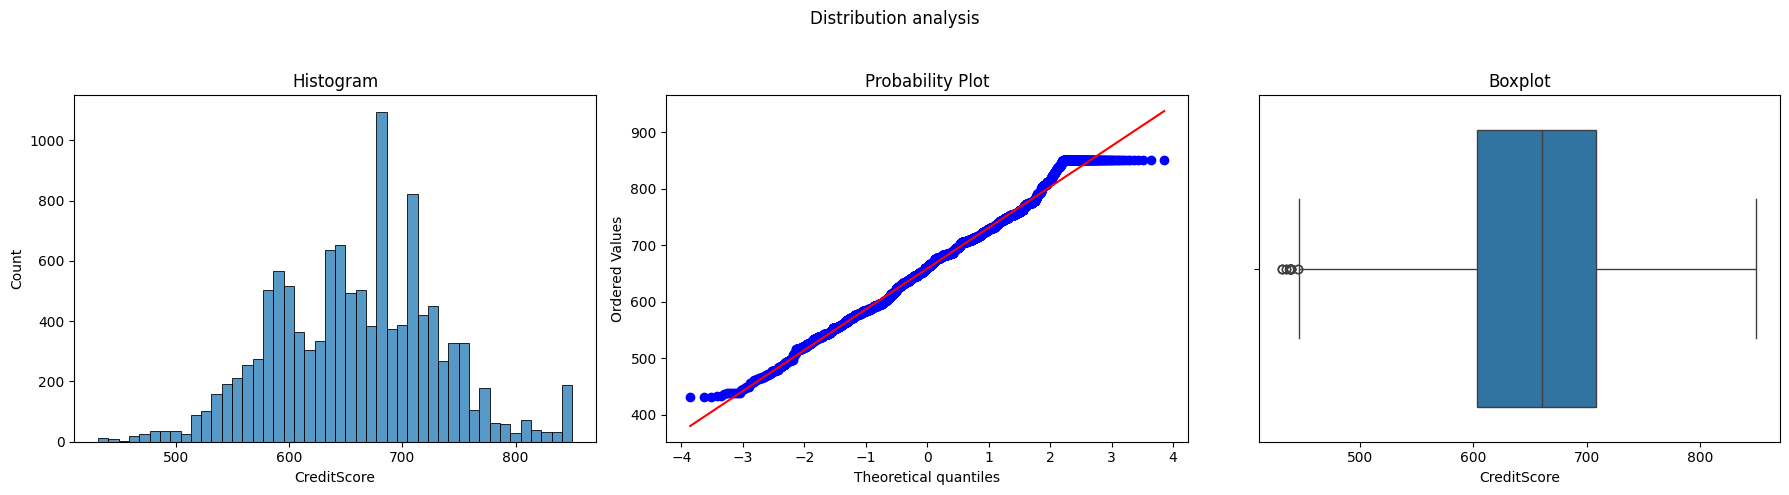

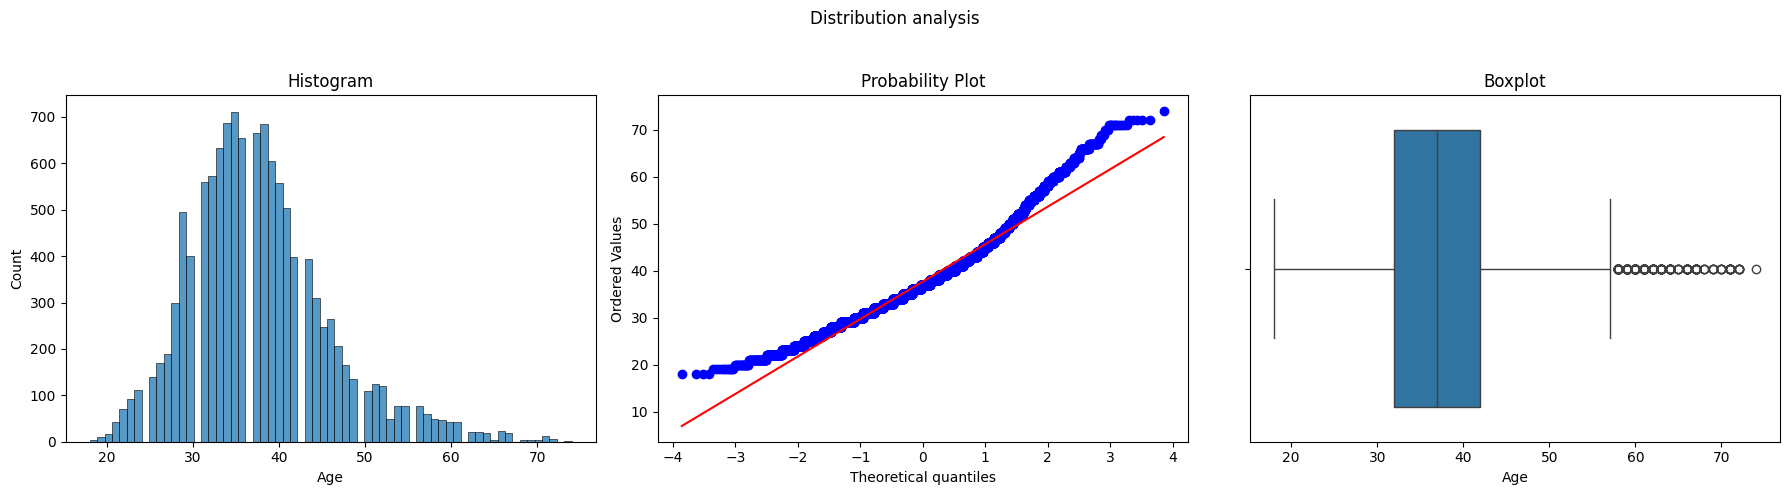

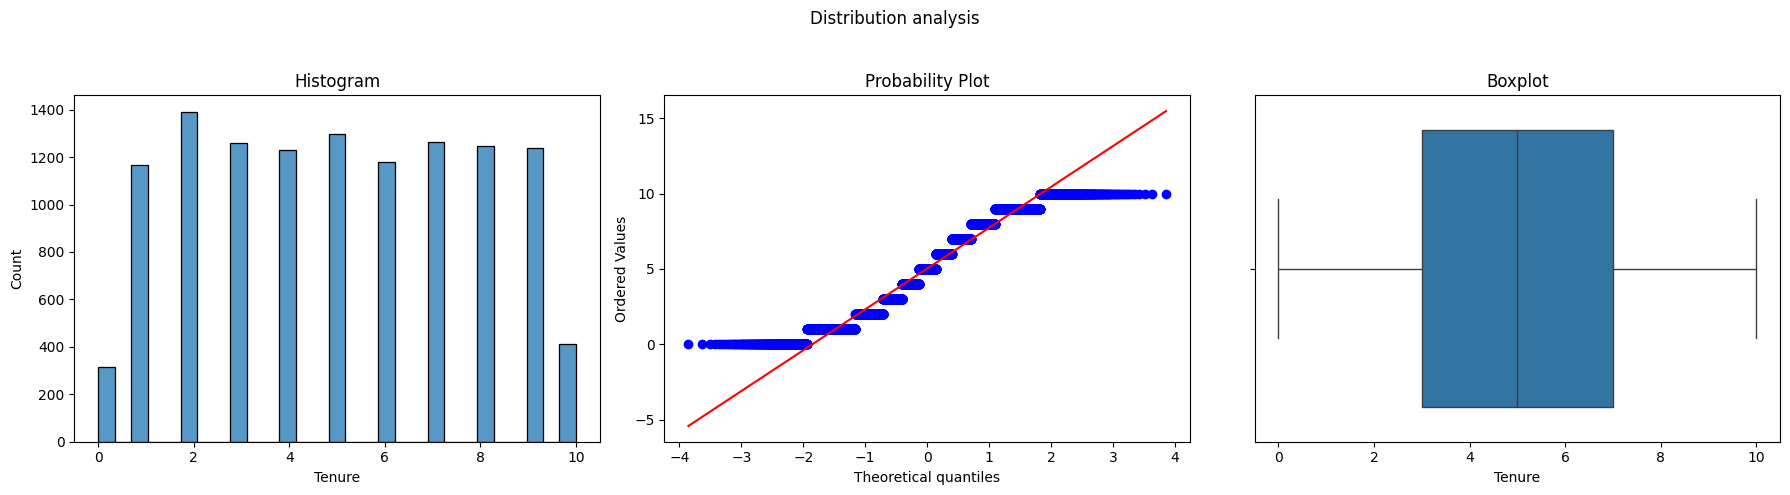

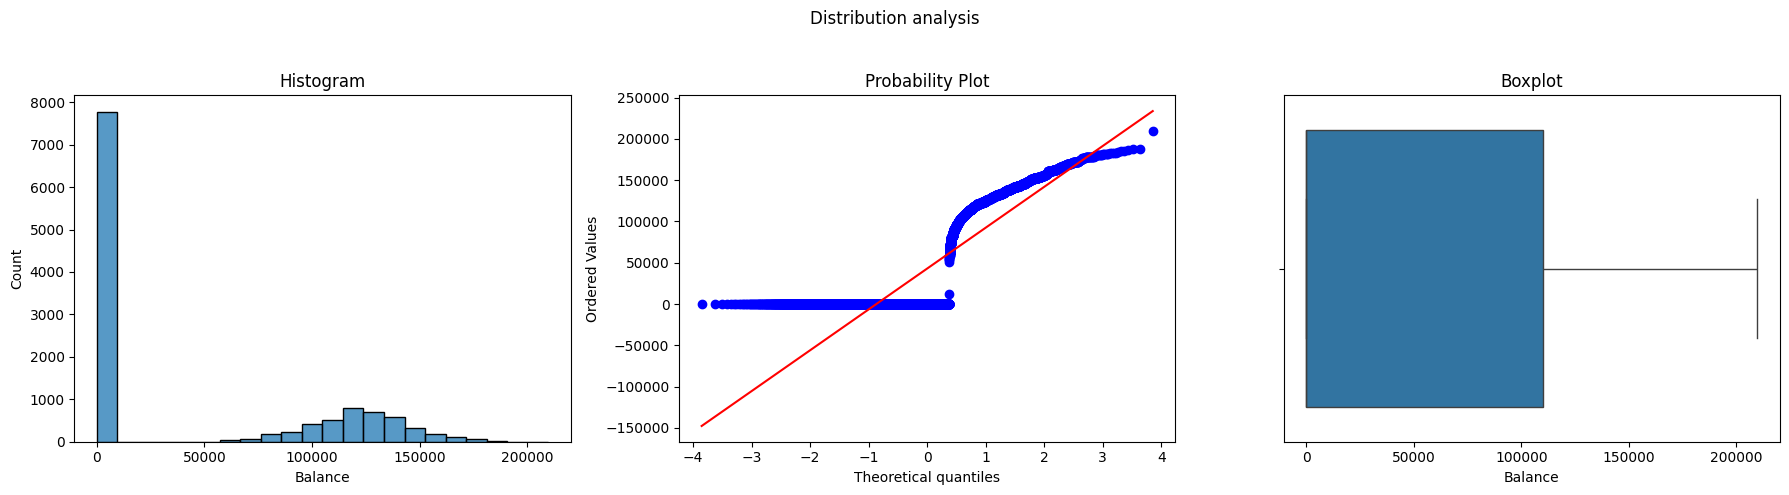

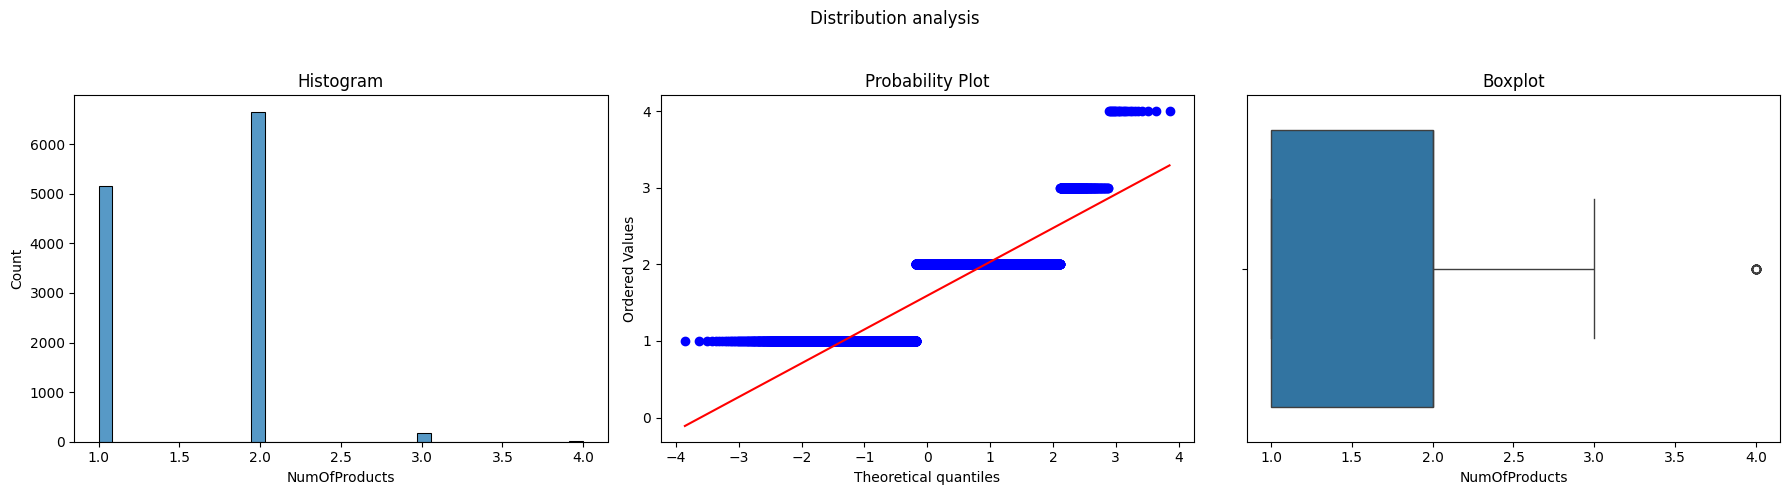

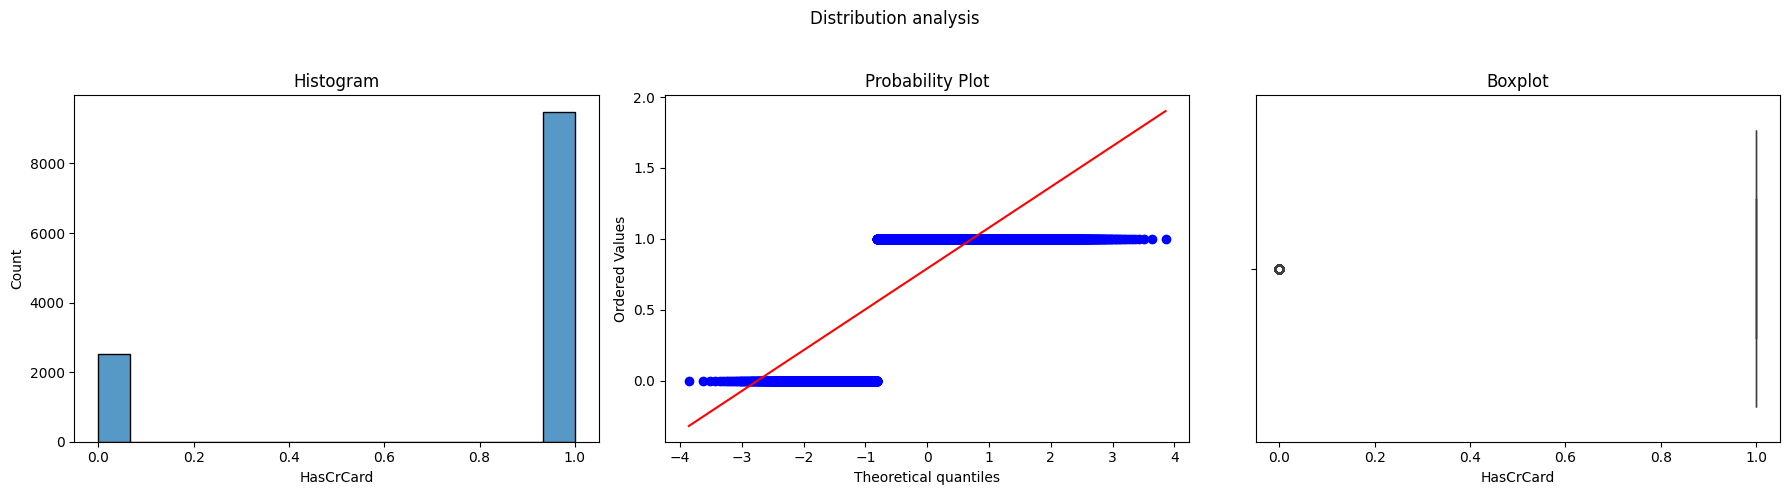

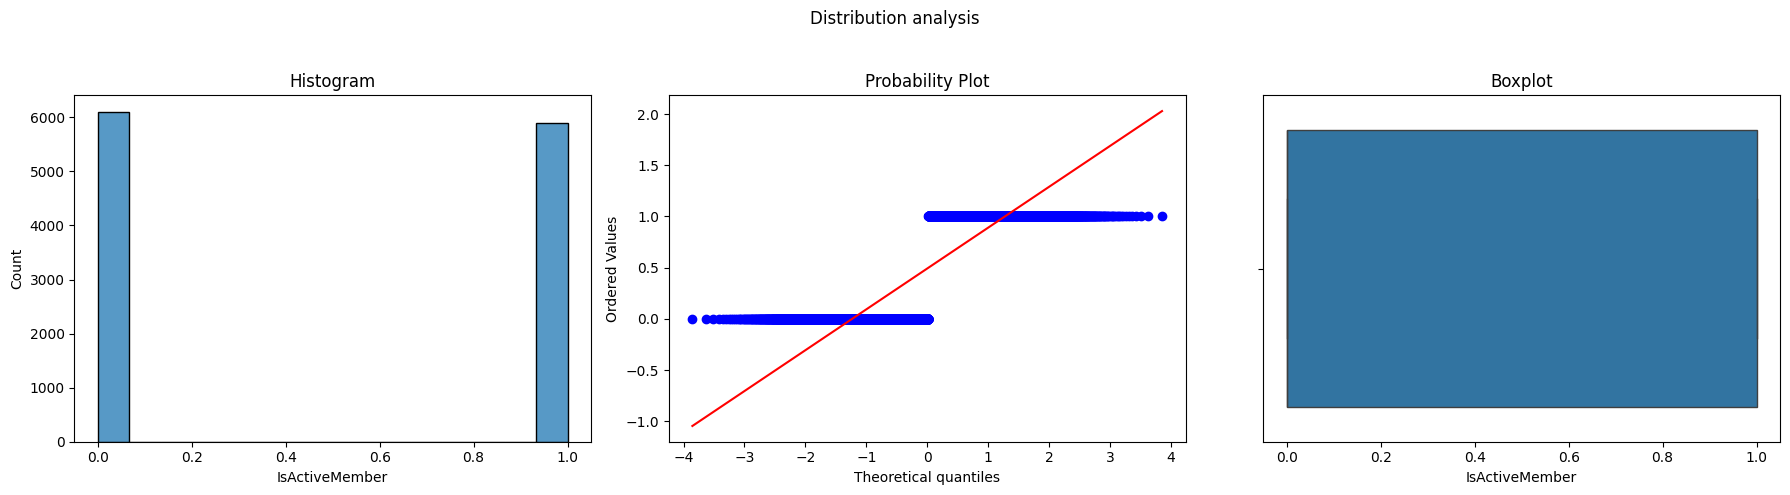

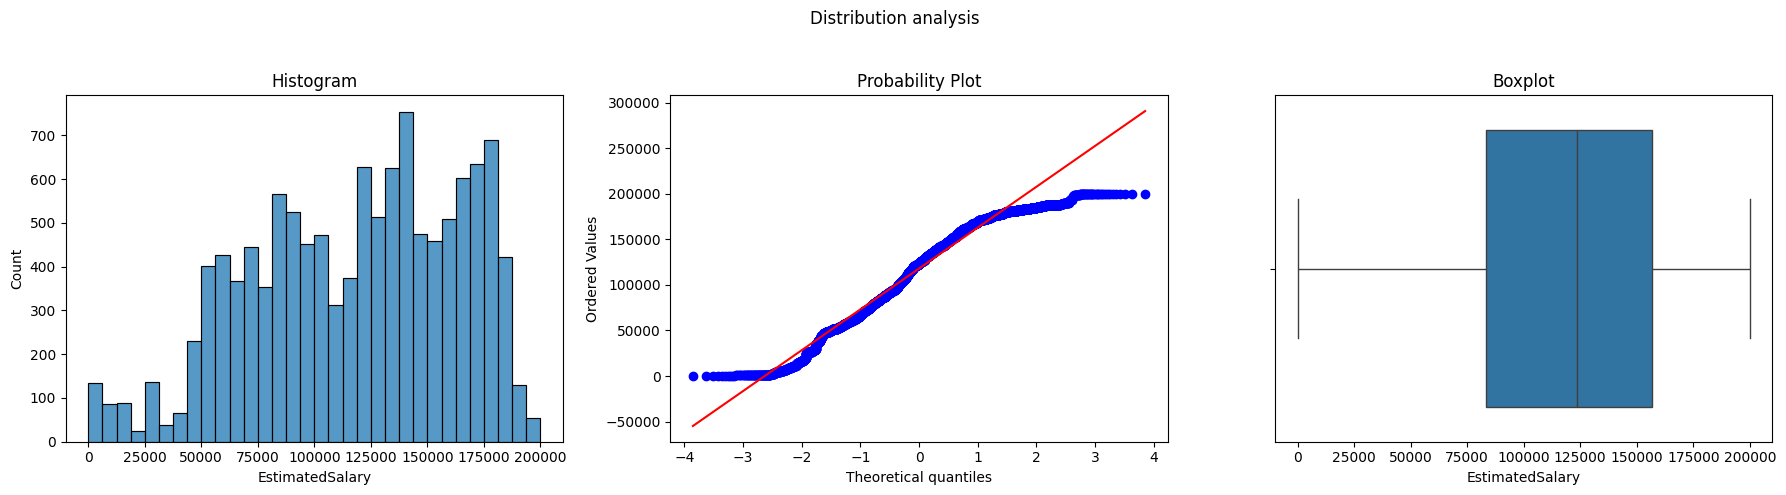

In [25]:
distribution_plot(train_inputs, numeric_cols)

Since the numerical features are of different orders, I propose to test four cases:

0. Base model -- numerical features are not scaled
1. Model with scaled features:
- StandardScaler
- RobusttScaler
- MinMaxScaler

To analyze whether there is a difference between the results in our case depending on which input data provides the best output results.
For scaling, we test three methods StandardScaler and MinMaxScaler and RobustScaler, since there are outliers in certain features, in particular in the case of age and credit rating.

StandardScaler feature scaling

In [26]:
stand_scaler = StandardScaler()
stand_scaler.fit(train_inputs[numeric_cols])

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [27]:
stand_train_inputs = train_inputs.copy()
stand_val_inputs = val_inputs.copy()

In [28]:
stand_train_inputs[numeric_cols] = stand_scaler.transform(stand_train_inputs[numeric_cols])
stand_val_inputs[numeric_cols] = stand_scaler.transform(stand_val_inputs[numeric_cols])

In [29]:
stand_train_inputs[numeric_cols].describe().round(2)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
count,12000.00,12000.00,12000.00,12000.00,12000.00,12000.00,12000.00,12000.00
mean,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-3.15,-2.42,-1.81,-0.72,-1.11,-1.94,-0.98,-2.59
25%,-0.77,-0.70,-0.73,-0.72,-1.11,0.52,-0.98,-0.76
50%,0.03,-0.08,-0.01,-0.72,0.77,0.52,-0.98,0.12
75%,0.68,0.53,0.71,1.12,0.77,0.52,1.02,0.85
max,2.64,4.46,1.79,2.78,4.52,0.52,1.02,1.80


RobustScaler feature scaling

In [30]:
robust_scaler = RobustScaler()
robust_scaler.fit(train_inputs[numeric_cols])

,"with_centering with_centering: bool, default=TrueIf `True`, center the data before scaling.This will cause :meth:`transform` to raise an exception when attemptedon sparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_scaling with_scaling: bool, default=TrueIf `True`, scale the data to interquartile range.",True
,"quantile_range quantile_range: tuple (q_min, q_max), 0.0 < q_min < q_max < 100.0, default=(25.0, 75.0)Quantile range used to calculate `scale_`. By default this is equal tothe IQR, i.e., `q_min` is the first quantile and `q_max` is the thirdquantile... versionadded:: 0.18","(25.0, ...)"
,"copy copy: bool, default=TrueIf `False`, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"unit_variance unit_variance: bool, default=FalseIf `True`, scale data so that normally distributed features have avariance of 1. In general, if the difference between the x-values of`q_max` and `q_min` for a standard normal distribution is greaterthan 1, the dataset will be scaled down. If less than 1, the datasetwill be scaled up... versionadded:: 0.24",False


In [31]:
robust_train_inputs = train_inputs.copy()
robust_val_inputs = val_inputs.copy()

In [32]:
robust_train_inputs[numeric_cols] = robust_scaler.transform(robust_train_inputs[numeric_cols])
robust_val_inputs[numeric_cols] = robust_scaler.transform(robust_val_inputs[numeric_cols])

In [33]:
robust_train_inputs[numeric_cols].describe().round(2)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
count,12000.00,12000.00,12000.00,12000.00,12000.00,12000.00,12000.00,12000.00
mean,-0.02,0.07,0.01,0.39,-0.41,-0.21,0.49,-0.08
std,0.69,0.81,0.70,0.54,0.53,0.41,0.50,0.62
min,-2.19,-1.90,-1.25,0.00,-1.00,-1.00,0.00,-1.68
25%,-0.55,-0.50,-0.50,0.00,-1.00,0.00,0.00,-0.55
50%,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-0.00
75%,0.45,0.50,0.50,1.00,0.00,0.00,1.00,0.45
max,1.80,3.70,1.25,1.91,2.00,0.00,1.00,1.04


MinMaxScaler feature scaling

In [34]:
minmax_scaler = MinMaxScaler()
minmax_scaler.fit(train_inputs[numeric_cols])

,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False


In [35]:
minmax_train_inputs = train_inputs.copy()
minmax_val_inputs = val_inputs.copy()

In [36]:
minmax_train_inputs[numeric_cols] = minmax_scaler.transform(minmax_train_inputs[numeric_cols])
minmax_val_inputs[numeric_cols] = minmax_scaler.transform(minmax_val_inputs[numeric_cols])

In [37]:
minmax_train_inputs[numeric_cols].describe().round(2)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
count,12000.00,12000.00,12000.00,12000.00,12000.00,12000.00,12000.00,12000.00
mean,0.54,0.35,0.50,0.21,0.20,0.79,0.49,0.59
std,0.17,0.15,0.28,0.29,0.18,0.41,0.50,0.23
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.41,0.25,0.30,0.00,0.00,1.00,0.00,0.42
50%,0.55,0.34,0.50,0.00,0.33,1.00,0.00,0.62
75%,0.66,0.43,0.70,0.52,0.33,1.00,1.00,0.78
max,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00


### Saving processed data

In [38]:
print('train_inputs', train_inputs.shape)
print('train_targets', train_targets.shape)

print('val_inputs', val_inputs.shape)
print('val_targets', val_targets.shape)

print('stand_train_inputs', stand_train_inputs.shape)
print('stand_val_inputs', stand_val_inputs.shape)

print('robust_train_inputs', robust_train_inputs.shape)
print('robust_val_inputs', robust_val_inputs.shape)

print('minmax_train_inputs', minmax_train_inputs.shape)
print('minmax_val_inputs', minmax_val_inputs.shape)

train_inputs (12000, 11)
train_targets (12000,)
val_inputs (3000, 11)
val_targets (3000,)
stand_train_inputs (12000, 11)
stand_val_inputs (3000, 11)
robust_train_inputs (12000, 11)
robust_val_inputs (3000, 11)
minmax_train_inputs (12000, 11)
minmax_val_inputs (3000, 11)


In [39]:
train_inputs.to_parquet('train_inputs.parquet')
train_targets.to_frame().to_parquet('train_targets.parquet')

val_inputs.to_parquet('val_inputs.parquet')
val_targets.to_frame().to_parquet('val_targets.parquet')

stand_train_inputs.to_parquet('stand_train_inputs.parquet')
stand_val_inputs.to_parquet('stand_val_inputs.parquet')

robust_train_inputs.to_parquet('robust_train_inputs.parquet')
robust_val_inputs.to_parquet('robust_val_inputs.parquet')

minmax_train_inputs.to_parquet('minmax_train_inputs.parquet')
minmax_val_inputs.to_parquet('minmax_val_inputs.parquet')

In [40]:
my_dir = r"G:\Skills\ML\Module_2\Класифікація_Kaggle_змагання"
files = os.listdir(my_dir)
print(files)

['HW_2_2_Логістична_регресія_з_scikit_learn.ipynb', 'HW_2_2_Логістична_регресія_з_scikit_learn_v2.ipynb', 'log_reg.joblib', 'minmax_train_inputs.parquet', 'minmax_val_inputs.parquet', 'robust_train_inputs.parquet', 'robust_val_inputs.parquet', 'sample_submission.csv', 'stand_train_inputs.parquet', 'stand_val_inputs.parquet', 'submission_log_reg_test.csv', 'test.csv', 'train.csv', 'train_inputs.parquet', 'train_targets.parquet', 'val_inputs.parquet', 'val_targets.parquet']


In [41]:
train_inputs = pd.read_parquet('train_inputs.parquet')
train_targets = pd.read_parquet('train_targets.parquet')['Exited']

val_inputs = pd.read_parquet('val_inputs.parquet')
val_targets = pd.read_parquet('val_targets.parquet')['Exited']

stand_train_inputs = pd.read_parquet('stand_train_inputs.parquet')
stand_val_inputs = pd.read_parquet('stand_val_inputs.parquet')

robust_train_inputs = pd.read_parquet('robust_train_inputs.parquet')
robust_val_inputs = pd.read_parquet('robust_val_inputs.parquet')

minmax_train_inputs = pd.read_parquet('minmax_train_inputs.parquet')
minmax_val_inputs = pd.read_parquet('minmax_val_inputs.parquet')

In [42]:
print('train_inputs', train_inputs.shape)
print('train_targets', train_targets.shape)

print('val_inputs', val_inputs.shape)
print('val_targets', val_targets.shape)

print('stand_train_inputs', stand_train_inputs.shape)
print('stand_val_inputs', stand_val_inputs.shape)

print('robust_train_inputs', robust_train_inputs.shape)
print('robust_val_inputs', robust_val_inputs.shape)

print('minmax_train_inputs', minmax_train_inputs.shape)
print('minmax_val_inputs', minmax_val_inputs.shape)

train_inputs (12000, 11)
train_targets (12000,)
val_inputs (3000, 11)
val_targets (3000,)
stand_train_inputs (12000, 11)
stand_val_inputs (3000, 11)
robust_train_inputs (12000, 11)
robust_val_inputs (3000, 11)
minmax_train_inputs (12000, 11)
minmax_val_inputs (3000, 11)


### Model building

At the data preparation stage, all processed data was saved only with those features that will be used for modeling, so we will use them immediately without redefinition.

No scaling

In [43]:
train_inputs.columns

Index(['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'GenderCode', 'Geography_Germany',
       'Geography_Spain'],
      dtype='object')

In [44]:
basic_model = LogisticRegression(solver = 'liblinear')
basic_model.fit(train_inputs, train_targets)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

Scaling features using StandardScaler

In [45]:
stand_model = LogisticRegression(solver = 'liblinear')
stand_model.fit(stand_train_inputs, train_targets)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

Feature scaling with RobustScaler

In [46]:
robust_model = LogisticRegression(solver = 'liblinear')
robust_model.fit(robust_train_inputs, train_targets)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

Feature scaling using MinMaxScaler

In [47]:
minmax_model = LogisticRegression(solver = 'liblinear')
minmax_model.fit(minmax_train_inputs, train_targets)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

### Analysis of simulation results

In [48]:
def classify_analysis(targets, inputs, model, name = ''):

    pred = model.predict(inputs)
    pred_proba = model.predict_proba(inputs)[:,1]
    pred_class = (pred_proba >= 0.5).astype(int)


    f1_score_value = f1_score(targets, pred_class, pos_label = True)
    print(f'F1 score on {name}: {round(f1_score_value, 4)}')


    cf = confusion_matrix(targets, pred_class, normalize = 'true')
    plt.figure()
    sns.heatmap(cf, annot = True)
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix'.format(name))


    fpr, tpr, thresholds = roc_curve(targets, pred_proba, pos_label = True)

    roc_auc = auc(fpr, tpr)
    print(f'AUROC for {name}: {round(roc_auc, 2)}')


    plt.figure()
    plt.plot(fpr, tpr, color = 'darkorange', lw =2, label = f'ROC curve (area = {round(roc_auc, 2)})')
    plt.plot([0, 1], [0, 1], color = 'navy', lw = 2, linestyle = '--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC for {name}')
    plt.legend(loc = "lower right")
    plt.show()


Base model without scaling

F1 score on Training: 0.4221
AUROC for Training: 0.8


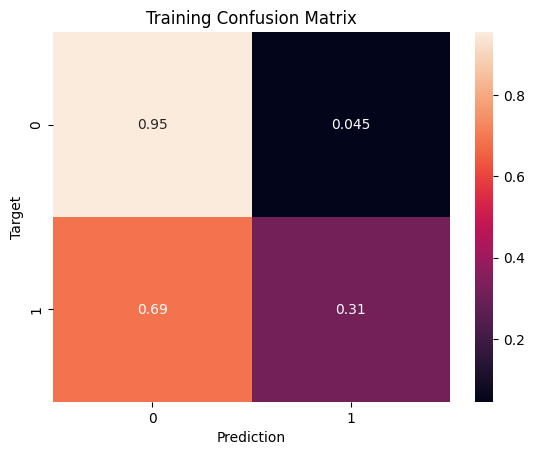

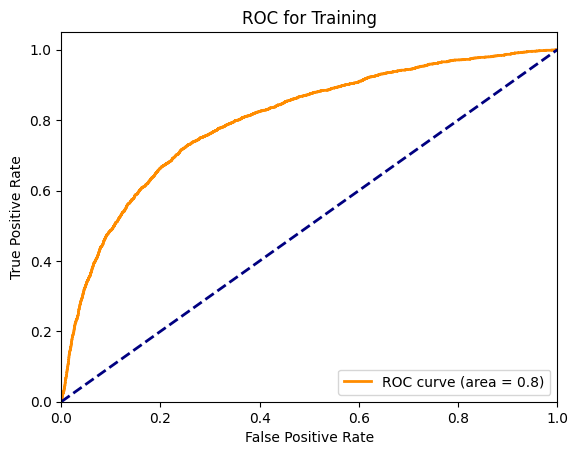

In [49]:
classify_analysis(train_targets, train_inputs, basic_model, 'Training')

F1 score on Validation: 0.3906
AUROC for Validation: 0.78


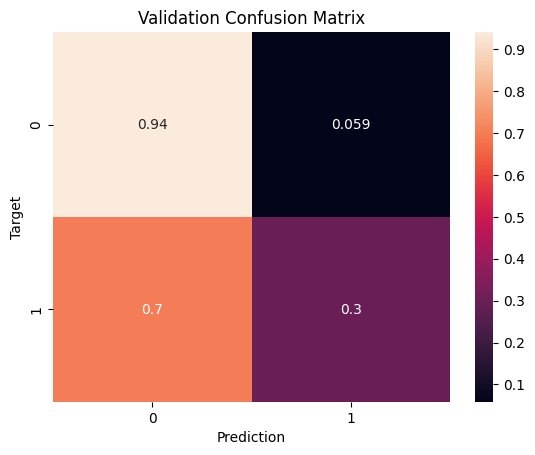

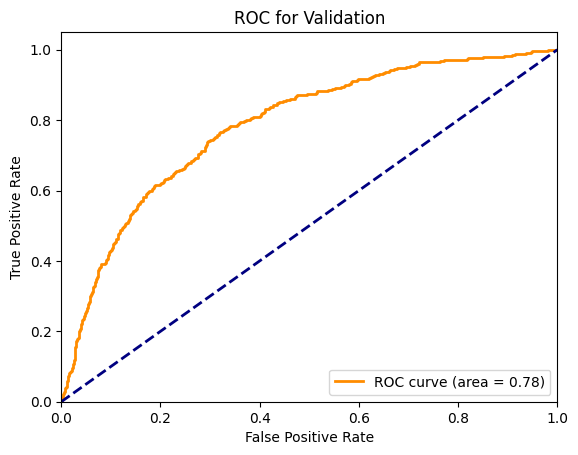

In [50]:
classify_analysis(val_targets, val_inputs, basic_model, 'Validation')

Scaling features using StandardScaler

F1 score on Training: 0.6405
AUROC for Training: 0.88


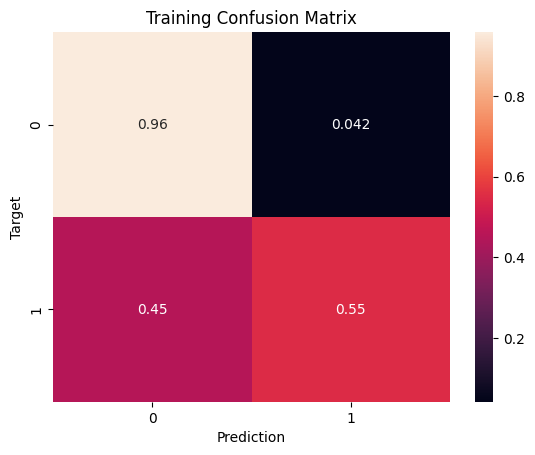

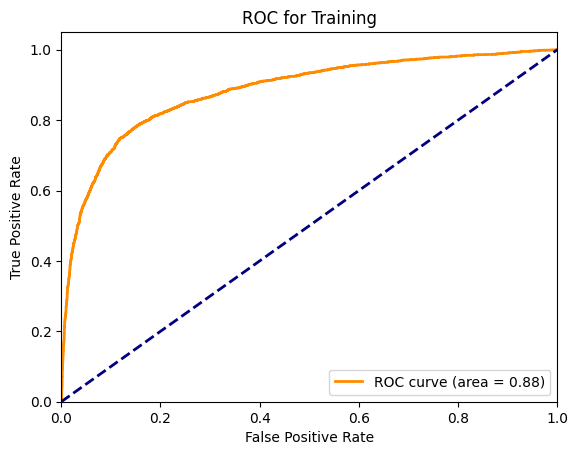

In [51]:
classify_analysis(train_targets, stand_train_inputs, stand_model, 'Training')

F1 score on Validation: 0.639
AUROC for Validation: 0.88


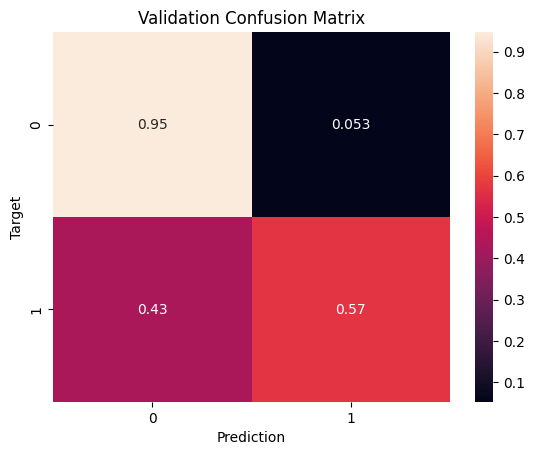

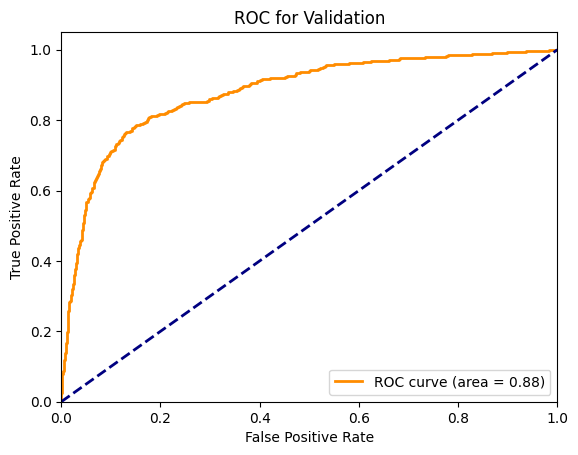

In [52]:
classify_analysis(val_targets, stand_val_inputs, stand_model, 'Validation')

Feature scaling with RobustScaler

F1 score on Training: 0.64
AUROC for Training: 0.88


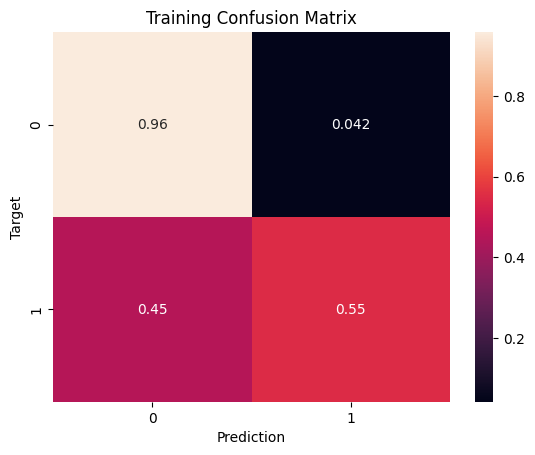

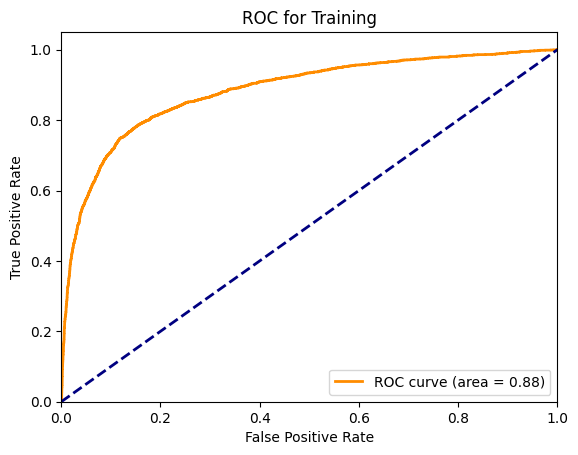

In [53]:
classify_analysis(train_targets, robust_train_inputs, robust_model, 'Training')

F1 score on Validation: 0.639
AUROC for Validation: 0.88


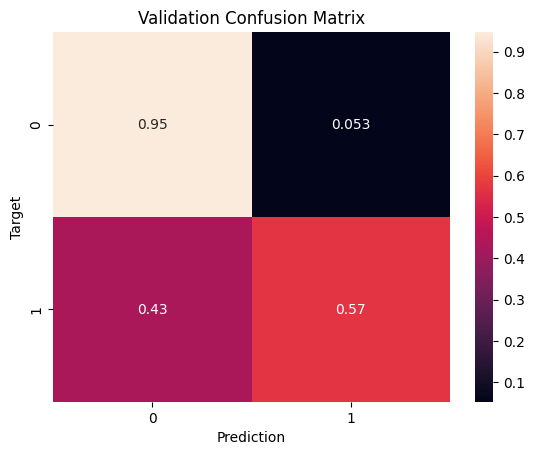

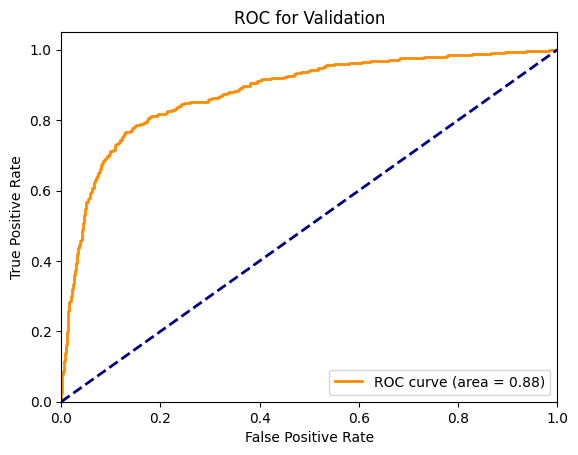

In [54]:
classify_analysis(val_targets, robust_val_inputs, robust_model, 'Validation')

Feature scaling using MinMaxScaler

F1 score on Training: 0.6348
AUROC for Training: 0.88


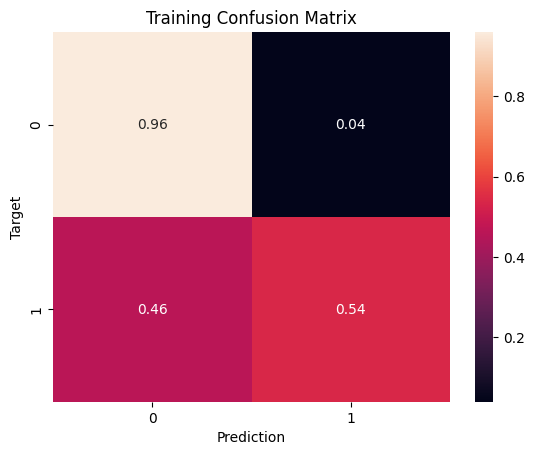

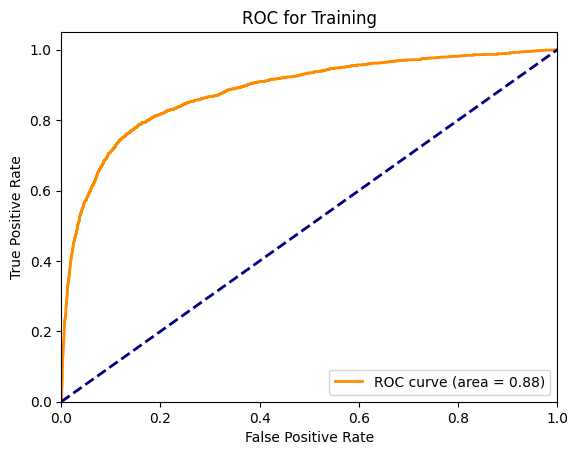

In [55]:
classify_analysis(train_targets, minmax_train_inputs, minmax_model, 'Training')

F1 score on Validation: 0.6399
AUROC for Validation: 0.88


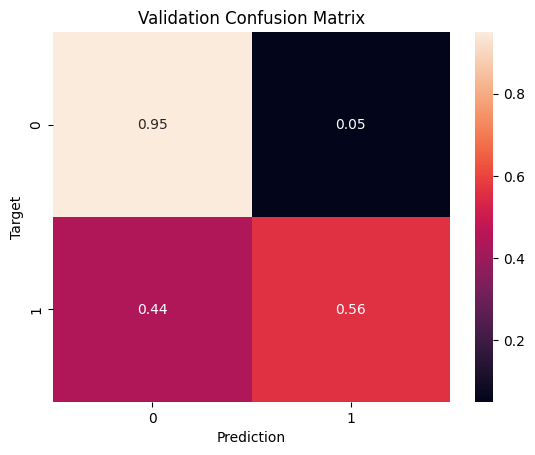

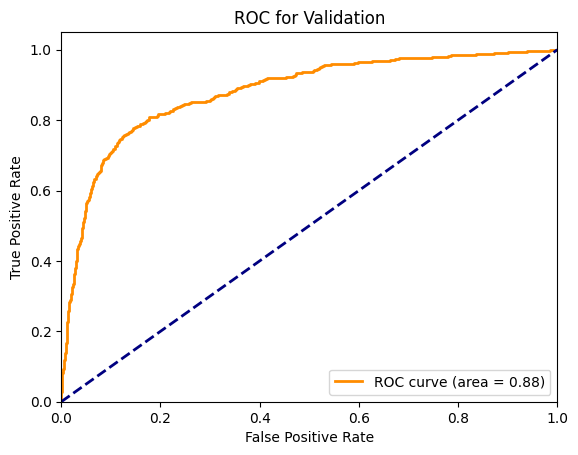

In [56]:
classify_analysis(val_targets, minmax_val_inputs, minmax_model, 'Validation')

According to the simulation results, we can confirm that data scaling really plays a significant role in improving model training, which is reflected in higher results.
At the same time, the three considered scaling methods showed quite close results. However, we have a more stable result on the model with standardized features (stand_model), so we choose it among others. The value of the area under the ROC curve 0.88 indicates a fairly good simulation result.

In [57]:
major_class = train_targets.value_counts().idxmax()
print("Мажоритарний клас:", major_class)

Мажоритарний клас: 0.0


In [58]:
train_major_pred = np.full(shape = len(train_targets), fill_value = major_class)
val_major_pred = np.full(shape = len(val_targets), fill_value = major_class)

In [59]:
stand_train_pred_probs = stand_model.predict_proba(stand_train_inputs)[:, 1]
stand_val_pred_probs = stand_model.predict_proba(stand_val_inputs)[:, 1]

stand_train_pred_class = (stand_train_pred_probs >= 0.5).astype(int)
stand_val_pred_class = (stand_val_pred_probs >= 0.5).astype(int)

In [60]:
print("Accuracy Training major class model:", round(accuracy_score(train_targets, train_major_pred), 4))
print("Accuracy Validation major class model:", round(accuracy_score(val_targets, val_major_pred), 4))

print("Accuracy Training stand_model:", round(accuracy_score(train_targets, stand_train_pred_class), 4))
print("Accuracy Validation stand_model:", round(accuracy_score(val_targets, stand_val_pred_class), 4))

Accuracy Training major class model: 0.7965
Accuracy Validation major class model: 0.7967
Accuracy Training stand_model: 0.8747
Accuracy Validation stand_model: 0.8697


Comparing the accuracy results of the model based on the majority class (0) and the model built on the basis of standardized features, we can note that the accuracy of the constructed model is higher than the model with the majority class, which is very good.

### Saving the model

In [61]:
log_reg = {
    'model': stand_model,
    'scaler': stand_scaler,
    'encoder': one_hot_encoder,
    'inputs_cols': inputs_cols,
    'target_col': target_col,
    'numeric_cols': numeric_cols,
    'categorical_cols': categorical_cols,
    'encoder_cols': one_hot_encoder_cols
}

In [62]:
joblib.dump(log_reg, 'log_reg.joblib')

['log_reg.joblib']

In [63]:
model2 = joblib.load('log_reg.joblib')

In [64]:
val_pred2 = model2['model'].predict(stand_val_inputs)
print("Accuracy Validation:", round(accuracy_score(val_targets, val_pred2), 4))

Accuracy Validation: 0.8697


### Data preparation function

In [66]:
import warnings
warnings.filterwarnings("ignore")

def predict_raw_df(model, scaler, encoder, encoder_cols, numeric_cols, map_cols, map_codes, input_df: pd.DataFrame):
    input_df[numeric_cols] = scaler.transform(input_df[numeric_cols])

    if isinstance(map_cols, str):
        map_cols_list = [map_cols]
    else:
        map_cols_list = map_cols

    for col in map_cols_list:
        input_df[f'{col}Code'] = input_df[col].map(map_codes)
    map_cols_mapped = [f'{col}Code' for col in map_cols_list]

    del_cat_column = input_df[encoder_cols].value_counts(normalize=True).idxmax()
    del_encode_column = f'{encoder_cols}_{del_cat_column}'

    encoded_array = encoder.transform(input_df[[encoder_cols]])

    encoded_df = pd.DataFrame(
        encoded_array,
        columns = encoder.get_feature_names_out([encoder_cols]),
        index = input_df.index
    )
    input_df = pd.concat([input_df, encoded_df], axis = 1)

    if del_encode_column in input_df.columns:
        input_df = input_df.drop(columns = [encoder_cols, del_encode_column])
    else:
        input_df = input_df.drop(columns = [encoder_cols])  
    encoded_cols = [col for col in encoded_df.columns if col != del_encode_column]

    numeric_cols = list(numeric_cols)
    encoded_cols = list(encoded_cols)

    X_input = input_df[numeric_cols + map_cols_mapped + encoded_cols]
    prob = model.predict_proba(X_input)[:,1]
    
    return prob

In [68]:
test_raw_df = pd.read_csv('test.csv')
test_raw_df['Exited'] = predict_raw_df(stand_model, stand_scaler, one_hot_encoder, encoder_cols, numeric_cols, map_cols, gender_codes, test_raw_df)

### Forming a submission

In [69]:
submission = pd.read_csv('sample_submission.csv')

In [70]:
submission['Exited'] = test_raw_df['Exited']

In [71]:
submission.head()

,id,Exited
0,15000,0.069640
1,15001,0.033649
2,15002,0.154641
3,15003,0.198942
4,15004,0.054321


In [72]:
submission.to_csv('submission_log_reg.csv', index = False)